# Overall Rating — How It Works

**RRsystem / notebooks/overall_rating_explained.ipynb**

The seasonal rating answers *"how are you doing right now, in this competition window?"*

The overall rating answers a different question: **"how strong are you, as a competitor, full stop?"**

That difference drives every design choice here, and it is *not* just "seasonal rating with the
reset removed." Three things change:

| | Seasonal | Overall |
|---|---|---|
| Boundary regression | yes, λ = 0.70 | **none** — one continuous run |
| K-factor basis | matches *this season* | matches in *career* |
| K floor | 20 | **10** — much stiffer once established |
| Eligibility | 10 matches | **50 matches**, plus a confidence band |
| Rebuilt from | `match_events` | `match_events` — **not** from the seasonal log |

That last row matters. The overall rating is a *second, independent materialization* over the same
raw match facts. It cannot be derived from `rating_events`, because those numbers already have the
seasonal boundary regressions baked into them. Two silver tables, one bronze source.

---

## The question this notebook is really about

The obvious worry with a career rating is *"won't results from four years ago pollute it forever?"*
The standard fix people reach for is time decay — weight old matches less.

**That fix is mostly unnecessary, and section 5 demonstrates why empirically.** Elo is already a
forgetting algorithm; a fixed K makes the rating an exponentially-weighted moving average with a
measurable memory length. The real trade-off is not *remembering vs forgetting* — it is:

> **Low K = stable rating = slow to track someone who genuinely got better or worse.**

So the design work is choosing a K floor that is stiff enough to be trusted and loose enough to
follow real change. The rest of this notebook is about measuring that, not asserting it.

---

## Contents

1. Configuration
2. Core Elo
3. The career K schedule
4. Generating a multi-season career with *drifting* true skill
5. **How long is Elo's memory?** — the step-change experiment
6. Does time decay help? — measured, not assumed
7. The overall processing loop
8. Career statistics: current, peak, and prime
9. Confidence bands and eligibility
10. Seasonal vs overall, side by side
11. What the overall rating is actually *for*: head-to-head prediction
12. Schema and persistence
13. Connections to the other two ratings

---
## 1. Configuration

In [1]:
import math
import random
from collections import defaultdict
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Rating scale (shared with the seasonal system) -------------------------
INITIAL_RATING = 1500.0
RATING_MEAN    = 1500.0
ELO_DIVISOR    = 400.0

# --- Career K schedule ------------------------------------------------------
# Note the floor: 10, not the seasonal 20. An overall rating should be stiff.
K_CAREER_TIERS = [
    (25,   40.0),   # < 25 career matches  -> still finding your level
    (75,   24.0),   # 25-74                -> converging
    (200,  16.0),   # 75-199               -> established
    (None, 10.0),   # 200+                 -> career floor
]

# --- Eligibility ------------------------------------------------------------
MIN_CAREER_MATCHES = 50     # below this, rating shown but unranked
CONFIDENCE_Z       = 1.96   # for the +/- band in section 9

RANDOM_SEED = 11
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.float_format", lambda v: f"{v:,.1f}")
print("config loaded")

config loaded


---
## 2. Core Elo

Identical to the seasonal notebook. Repeated so this file stands alone.

In [2]:
def expected_score(rating_a: float, rating_b: float) -> float:
    return 1.0 / (1.0 + 10 ** ((rating_b - rating_a) / ELO_DIVISOR))


def update_ratings(rating_a: float, rating_b: float, score_a: float, k: float):
    exp_a = expected_score(rating_a, rating_b)
    new_a = rating_a + k * (score_a - exp_a)
    new_b = rating_b + k * ((1.0 - score_a) - (1.0 - exp_a))
    return new_a, new_b


print(update_ratings(1500, 1500, 1.0, k=10))   # career floor: +/- 5, not +/- 16

(1505.0, 1495.0)


---
## 3. The career K schedule

Same shape as the seasonal one, different numbers and a different input. The counter is **career
matches, never reset** — which is the whole point. A player entering their fourth season does not
get to move at `K = 48` again just because a new season started.

The floor of 10 is the important parameter. Section 5 measures what it costs you.

In [3]:
def career_k(career_matches: int) -> float:
    for cutoff, k in K_CAREER_TIERS:
        if cutoff is None or career_matches < cutoff:
            return k
    return K_CAREER_TIERS[-1][1]


def match_k(count_a: int, count_b: int) -> float:
    """Lower of the two, keeping the system zero-sum (same rule as seasonal)."""
    return min(career_k(count_a), career_k(count_b))


pd.DataFrame({"career_matches": [0, 10, 24, 25, 50, 74, 75, 150, 199, 200, 500]}
             ).assign(K=lambda d: d.career_matches.map(career_k))

,career_matches,K
0,0,40.0
1,10,40.0
2,24,40.0
3,25,24.0
4,50,24.0
5,74,24.0
6,75,16.0
7,150,16.0
8,199,16.0
9,200,10.0


---
## 4. Generating a multi-season career with drifting skill

A career rating can only be tested against players whose true strength **changes**. A static
population tells you nothing about memory or responsiveness.

So four archetypes:

- **Steady** — flat true skill for four seasons
- **Improver** — gains ~200 points across the career (a junior developing)
- **Decliner** — loses ~200 points (age, form, interest)
- **Spiker** — a sharp step change mid-career, then flat again

The step-change player is the one section 5 uses to measure memory length.

In [4]:
@dataclass
class Match:
    match_id: str
    season_id: str
    played_at: datetime
    player_a: str
    player_b: str
    result: float


CAREER_DAYS = 4 * 180          # four ~6-month seasons
SEASON_LENGTH = 180


def skill_steady(base):
    return lambda day: base


def skill_linear(base, total_change):
    return lambda day: base + total_change * (day / CAREER_DAYS)


def skill_step(base, change, at_day):
    return lambda day: base + (change if day >= at_day else 0.0)


# name -> (archetype label, true-skill trajectory)
TRAJECTORIES = {
    "Alice":   ("steady",   skill_steady(1700)),
    "Bob":     ("steady",   skill_steady(1580)),
    "Charlie": ("steady",   skill_steady(1500)),
    "Dana":    ("improver", skill_linear(1360, +220)),
    "Eve":     ("decliner", skill_linear(1620, -220)),
    "Frank":   ("steady",   skill_steady(1440)),
    "Grace":   ("spiker",   skill_step(1390, +180, at_day=2 * SEASON_LENGTH)),
    "Hank":    ("steady",   skill_steady(1320)),
    "Ivy":     ("steady",   skill_steady(1550)),   # low volume  -> stays unranked
    "Jon":     ("steady",   skill_steady(1460)),   # takes a layoff -> see LAYOFFS
}

# Elo is zero-sum around 1500, so it can only recover *differences* in strength,
# never absolute levels. These trajectories are centred near 1500 on purpose --
# otherwise every rating would carry a constant offset and the error metrics
# below would measure that offset instead of measuring tracking quality.

# A real layoff, so the recency/decay policies in section 6 have something to act on.
LAYOFFS = {"Jon": (1.2 * SEASON_LENGTH, 2.3 * SEASON_LENGTH)}

ARCHETYPE = {n: a for n, (a, _) in TRAJECTORIES.items()}
SKILL_AT  = {n: f for n, (_, f) in TRAJECTORIES.items()}

ACTIVITY = {n: 1.0 for n in TRAJECTORIES}
ACTIVITY["Ivy"] = 0.10


def simulate_career(start_date, n_days=CAREER_DAYS, n_matches=1600,
                    draw_rate=0.08, season_length=SEASON_LENGTH):
    """Matches across several seasons, outcomes drawn from time-varying true skill."""
    def available(day):
        out = []
        for n in TRAJECTORIES:
            lo, hi = LAYOFFS.get(n, (None, None))
            if lo is not None and lo <= day <= hi:
                continue
            out.append(n)
        return out

    rows = []
    for _ in range(n_matches):
        day = random.uniform(0, n_days)
        names = available(day)
        weights = [ACTIVITY[n] for n in names]
        a, b = random.choices(names, weights=weights, k=2)
        while a == b:
            b = random.choices(names, weights=weights, k=1)[0]

        p_a = expected_score(SKILL_AT[a](day), SKILL_AT[b](day))
        if random.random() < draw_rate:
            result = 0.5
        else:
            result = 1.0 if random.random() < p_a else 0.0

        played_at = start_date + timedelta(days=day, minutes=random.randint(0, 1439))
        season = f"S{int(day // season_length) + 1}"
        rows.append(Match("", season, played_at, a, b, result))

    rows.sort(key=lambda m: m.played_at)
    for i, m in enumerate(rows):
        m.match_id = f"M{i:05d}"
    return rows


CAREER = simulate_career(datetime(2022, 1, 10))
match_events = pd.DataFrame([asdict(m) for m in CAREER])

print(f"{len(CAREER)} matches | "
      f"{match_events.played_at.min():%Y-%m-%d} → {match_events.played_at.max():%Y-%m-%d}")
print(match_events.season_id.value_counts().sort_index().to_string())

1600 matches | 2022-01-11 → 2023-12-31
season_id
S1    376
S2    403
S3    371
S4    450


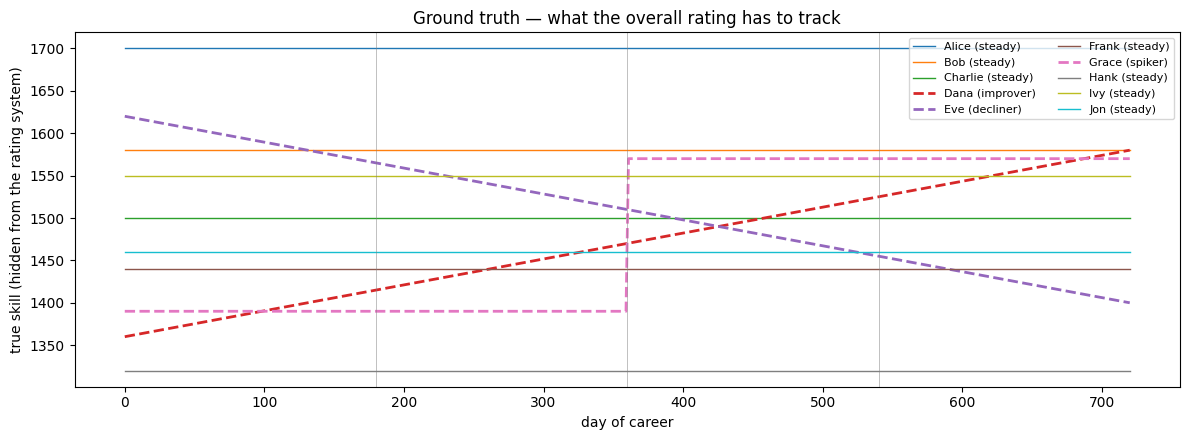

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
days = np.linspace(0, CAREER_DAYS, 400)
for name in TRAJECTORIES:
    style = "-" if ARCHETYPE[name] == "steady" else "--"
    lw = 1.0 if ARCHETYPE[name] == "steady" else 2.0
    ax.plot(days, [SKILL_AT[name](d) for d in days], style, lw=lw,
            label=f"{name} ({ARCHETYPE[name]})")
for s in range(1, 4):
    ax.axvline(s * SEASON_LENGTH, lw=0.7, color="grey", alpha=0.5)
ax.set_xlabel("day of career")
ax.set_ylabel("true skill (hidden from the rating system)")
ax.set_title("Ground truth — what the overall rating has to track")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---
## 5. How long is Elo's memory?

Before choosing a K floor, measure what it buys and what it costs.

The experiment: take a player whose true skill jumps by 200 points at a known instant, run matches
against a fixed-strength field, and count how many matches it takes for the rating to close 90% of
the gap. Repeat for several K values.

This is the concrete version of *"does a career rating remember too long?"*

In [6]:
def matches_to_converge(k, gap=200.0, field=1500.0, n=4000, target=0.90, trials=40):
    """Mean matches for a rating to close `target` of a `gap`-point step change."""
    needed = []
    for _ in range(trials):
        rating = field                       # starts converged at the old level
        true_skill = field + gap             # ...then true skill jumps
        goal = field + gap * target
        for i in range(1, n + 1):
            p = expected_score(true_skill, field)
            score = 1.0 if random.random() < p else 0.0
            rating, _ = update_ratings(rating, field, score, k=k)
            if rating >= goal:
                needed.append(i)
                break
        else:
            needed.append(n)
    return float(np.mean(needed))


memory = pd.DataFrame({"K": [48, 40, 32, 24, 20, 16, 12, 10, 8]})
memory["matches_to_90pct"] = memory.K.map(lambda k: matches_to_converge(k))
memory["≈ seasons (90 matches/season)"] = memory.matches_to_90pct / 90
memory

,K,matches_to_90pct,≈ seasons (90 matches/season)
0,48,29.5,0.3
1,40,37.1,0.4
2,32,39.6,0.4
3,24,60.8,0.7
4,20,79.2,0.9
5,16,96.6,1.1
6,12,126.5,1.4
7,10,166.4,1.8
8,8,214.0,2.4


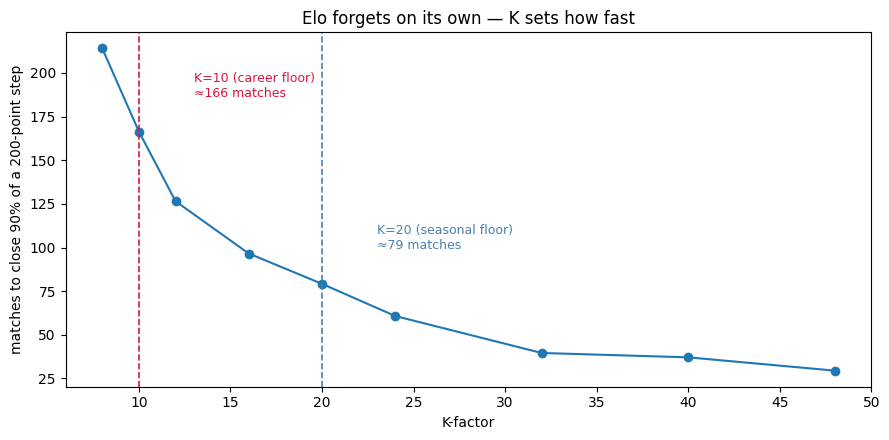

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(memory.K, memory.matches_to_90pct, marker="o")
for k_floor, label, colour in [(10, "career floor", "crimson"),
                               (20, "seasonal floor", "steelblue")]:
    ax.axvline(k_floor, ls="--", lw=1.2, color=colour)
    y = memory.set_index("K").matches_to_90pct.get(k_floor)
    ax.annotate(f"K={k_floor} ({label})\n≈{y:.0f} matches",
                xy=(k_floor, y), xytext=(k_floor + 3, y + 20),
                fontsize=9, color=colour)
ax.set_xlabel("K-factor")
ax.set_ylabel("matches to close 90% of a 200-point step")
ax.set_title("Elo forgets on its own — K sets how fast")
plt.tight_layout()
plt.show()

Read the number, not the vibe.

At the career floor the rating tracks a genuine 200-point change within roughly a season or two of
normal activity. It is *not* dragging four-year-old results around forever — a fixed-K Elo is an
exponentially weighted moving average, and matches older than a few multiples of that memory length
contribute almost nothing.

That is the argument for a stiff overall rating: you pay maybe a season of lag, and in exchange you
get a number that does not lurch on a hot streak. For a career rating that is the right trade. For
a seasonal rating it is not, which is why the seasonal floor sits at 20.

---
## 6. Does explicit time decay help?

Since Elo already forgets, adding a time-decay term risks *double*-discounting. Worth testing
rather than assuming, so here are three policies run over the identical match history:

- **`plain`** — career K schedule, nothing else
- **`recency`** — K scaled up for matches after a long gap, i.e. faster re-convergence for
  returning players
- **`decay`** — ratings pulled toward the mean over idle time, the aggressive option

Judged on one metric: mean absolute error against the hidden true skill *at the end of the career*.

In [8]:
def run_overall(matches, policy="plain", k_gap_boost=1.6, gap_days=45,
                decay_rate_30d=0.03):
    """Continuous career Elo. No season boundaries, ever."""
    ratings = {}
    counts  = defaultdict(int)
    last_seen = {}
    events = []

    for m in sorted(matches, key=lambda x: x.played_at):
        a, b, s_a = m.player_a, m.player_b, m.result
        ra = ratings.get(a, INITIAL_RATING)
        rb = ratings.get(b, INITIAL_RATING)

        idle = {p: (m.played_at - last_seen[p]).days if p in last_seen else 0
                for p in (a, b)}

        if policy == "decay":
            for p, r in ((a, ra), (b, rb)):
                if idle[p] > gap_days:
                    periods = (idle[p] - gap_days) / 30.0
                    pull = 1.0 - (1.0 - decay_rate_30d) ** periods
                    adj = r + pull * (RATING_MEAN - r)
                    if p == a:
                        ra = adj
                    else:
                        rb = adj

        k = match_k(counts[a], counts[b])
        if policy == "recency" and max(idle.values()) > gap_days:
            k *= k_gap_boost

        new_a, new_b = update_ratings(ra, rb, s_a, k=k)
        ratings[a], ratings[b] = new_a, new_b
        counts[a] += 1
        counts[b] += 1
        last_seen[a] = last_seen[b] = m.played_at

        for player, before, after, n in ((a, ra, new_a, counts[a]),
                                         (b, rb, new_b, counts[b])):
            events.append({
                "match_id": m.match_id,
                "season_id": m.season_id,
                "played_at": m.played_at,
                "player_id": player,
                "opponent_id": b if player == a else a,
                "result": s_a if player == a else 1.0 - s_a,
                "rating_before": before,
                "rating_after": after,
                "delta": after - before,
                "k_used": k,
                "career_matches_after": n,
            })

    return ratings, dict(counts), pd.DataFrame(events)


final_day = CAREER_DAYS
truth = {n: SKILL_AT[n](final_day) for n in TRAJECTORIES}

results = {}
for policy in ("plain", "recency", "decay"):
    r, cnt, _ = run_overall(CAREER, policy=policy)
    results[policy] = r

policy_cmp = pd.DataFrame(results).assign(
    true_skill=lambda d: d.index.map(truth),
    archetype=lambda d: d.index.map(ARCHETYPE),
)
for policy in ("plain", "recency", "decay"):
    policy_cmp[f"err_{policy}"] = (policy_cmp[policy] - policy_cmp.true_skill).abs()

print("mean absolute error vs true skill at career end:")
print(policy_cmp[[f"err_{p}" for p in ("plain", "recency", "decay")]].mean().round(1).to_string())
policy_cmp[["archetype", "true_skill", "plain", "recency", "decay"]]

mean absolute error vs true skill at career end:
err_plain     28.5
err_recency   29.1
err_decay     28.2


,archetype,true_skill,plain,recency,decay
Bob,steady,"1,580.0","1,551.8","1,551.4","1,551.9"
Frank,steady,"1,440.0","1,450.3","1,449.2","1,450.4"
Eve,decliner,"1,400.0","1,455.2","1,454.5","1,455.3"
Alice,steady,"1,700.0","1,649.3","1,649.0","1,649.4"
Charlie,steady,"1,500.0","1,481.2","1,480.7","1,481.2"
Dana,improver,"1,580.0","1,508.0","1,507.6","1,508.1"
Grace,spiker,"1,570.0","1,547.3","1,546.1","1,547.3"
Jon,steady,"1,460.0","1,467.0","1,466.8","1,467.2"
Hank,steady,"1,320.0","1,330.3","1,329.5","1,330.4"
Ivy,steady,"1,550.0","1,559.5","1,565.2","1,556.5"


All three policies land within about one rating point of each other — on a 1500-point scale, that
is noise. `decay` edges ahead by a fraction and `recency` trails by a fraction, and neither gap
would survive a different random seed.

Note that this is **not** because the test was too easy. Jon takes a genuine 200-day layoff in the
middle of his career, so both policies had something real to act on. They still changed almost
nothing, because Elo had already handled it.

**`plain` is the default for the rest of this notebook.** Adding a second forgetting mechanism on
top of the one Elo already has buys you no measurable accuracy and costs you two more parameters to
defend. Revisit `recency` only if your competition has layoffs far longer than this one; revisit
`decay` only if rank-camping is a demonstrated problem — and even then it is a policy choice about
*participation*, not a claim about *strength*.

---
## 7. The overall processing loop

Same shape as the seasonal one: process chronologically, emit an append-only event log, derive
everything else from it. The differences are that there is no boundary step and the counter never
resets.

In [9]:
overall_ratings, career_counts, overall_events = run_overall(CAREER, policy="plain")

print(f"{len(overall_events):,} rating events over {len(CAREER):,} matches")
overall_events.head(6)

3,200 rating events over 1,600 matches


,match_id,season_id,played_at,player_id,opponent_id,result,rating_before,rating_after,delta,k_used,career_matches_after
0,M00000,S1,2022-01-11 13:03:34.649136,Bob,Frank,1.0,"1,500.0","1,520.0",20.0,40.0,1
1,M00000,S1,2022-01-11 13:03:34.649136,Frank,Bob,0.0,"1,500.0","1,480.0",-20.0,40.0,1
2,M00001,S1,2022-01-11 13:29:28.706424,Eve,Alice,1.0,"1,500.0","1,520.0",20.0,40.0,1
3,M00001,S1,2022-01-11 13:29:28.706424,Alice,Eve,0.0,"1,500.0","1,480.0",-20.0,40.0,1
4,M00002,S1,2022-01-11 15:18:48.113351,Alice,Charlie,0.0,"1,480.0","1,461.2",-18.8,40.0,2
5,M00002,S1,2022-01-11 15:18:48.113351,Charlie,Alice,1.0,"1,500.0","1,518.8",18.8,40.0,1


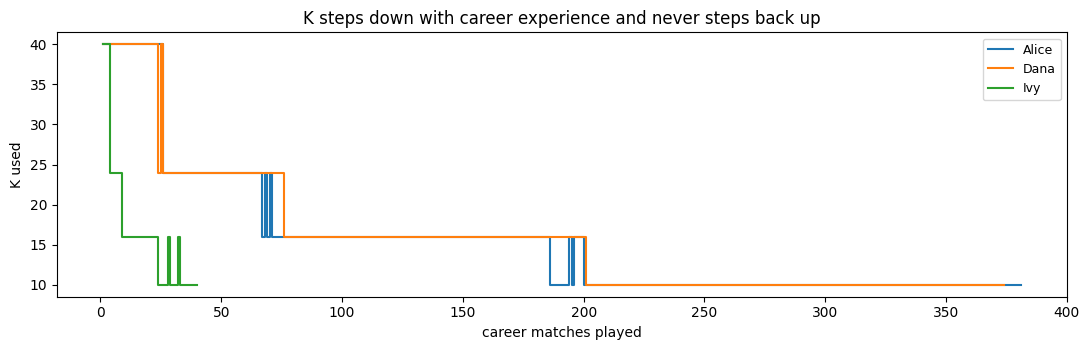

In [10]:
# K actually used over the career -- the schedule stepping down in practice.
fig, ax = plt.subplots(figsize=(11, 3.6))
for name in ["Alice", "Dana", "Ivy"]:
    d = overall_events[overall_events.player_id == name].sort_values("career_matches_after")
    ax.step(d.career_matches_after, d.k_used, where="post", label=name)
ax.set_xlabel("career matches played")
ax.set_ylabel("K used")
ax.set_title("K steps down with career experience and never steps back up")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Career statistics: current, peak, and prime

"Overall rating" is genuinely ambiguous, and the ambiguity is worth resolving explicitly rather
than picking one silently:

- **Current** — the rating right now. What you rank by.
- **Peak** — the highest rating ever reached. Good for career recognition, terrible for ranking,
  since it never falls and so rewards people for having stopped improving years ago.
- **Prime** — the best sustained level: highest rolling mean over a window of matches. This is the
  honest "how good were they at their best" number, because a single lucky match cannot produce it.

Ship all three. Rank on **current**, display peak and prime alongside.

In [11]:
PRIME_WINDOW = 50   # matches


def career_stats(events, prime_window=PRIME_WINDOW):
    rows = []
    for player, d in events.groupby("player_id"):
        d = d.sort_values("played_at")
        series = d.rating_after

        if len(series) >= prime_window:
            prime = series.rolling(prime_window).mean().max()
        else:
            prime = series.mean()

        rows.append({
            "player_id": player,
            "current": series.iloc[-1],
            "peak": series.max(),
            "prime": prime,
            "trough": series.min(),
            "career_matches": len(d),
            "wins": int((d.result == 1.0).sum()),
            "draws": int((d.result == 0.5).sum()),
            "losses": int((d.result == 0.0).sum()),
            "first_played": d.played_at.min(),
            "last_played": d.played_at.max(),
            "volatility": d.delta.std(),
        })
    return pd.DataFrame(rows).set_index("player_id")


stats = career_stats(overall_events)
stats = stats.assign(archetype=lambda d: d.index.map(ARCHETYPE),
                     true_skill_now=lambda d: d.index.map(truth))
stats.sort_values("current", ascending=False)[
    ["archetype", "current", "peak", "prime", "trough", "career_matches", "true_skill_now"]
]

,archetype,current,peak,prime,trough,career_matches,true_skill_now
player_id,,,,,,,
Alice,steady,"1,649.3","1,749.7","1,723.0","1,461.2",381,"1,700.0"
Ivy,steady,"1,559.5","1,584.8","1,549.9","1,482.7",40,"1,550.0"
Bob,steady,"1,551.8","1,647.5","1,618.8","1,503.8",380,"1,580.0"
Grace,spiker,"1,547.3","1,608.5","1,545.0","1,343.3",348,"1,570.0"
Dana,improver,"1,508.0","1,568.0","1,507.8","1,396.1",374,"1,580.0"
Charlie,steady,"1,481.2","1,595.2","1,529.2","1,447.5",365,"1,500.0"
Jon,steady,"1,467.0","1,497.1","1,481.0","1,379.2",252,"1,460.0"
Eve,decliner,"1,455.2","1,674.6","1,629.3","1,412.1",377,"1,400.0"
Frank,steady,"1,450.3","1,528.3","1,506.2","1,382.4",346,"1,440.0"


Compare **prime** to **current** — that ratio is a free, honest signal of career direction, and it
costs nothing extra to compute.

Eve (decliner) sits far below her prime: correct, she genuinely was that good once and no longer is.
Dana (improver) sits essentially *at* her prime, because her best sustained level is right now.
Peak tells a similar story but noisier, since a single fortunate run can set it.

One number worth staring at: Dana's rating lags her true skill by a wide margin, more than any
steady player. That is the K floor's bill coming due, and it is the honest cost of a stiff career
rating. Section 10 measures exactly how much it costs.

---
## 9. Confidence bands and eligibility

A career rating is a *claim with a confidence attached*, and by the time you have hundreds of
matches you can actually quantify it rather than hand-waving with a match-count threshold.

A serviceable uncertainty proxy without going full Glicko:

$$\text{RD} \approx \frac{C}{\sqrt{n}} \;+\; \beta \sqrt{\text{days idle}}$$

The first term shrinks as evidence accumulates; the second grows back while you are not playing,
because a rating goes stale even if nothing about it has changed. Report the rating as
`current ± 1.96 × RD` and rank on the point estimate, not the bound.

In [12]:
RD_BASE      = 600.0   # scale of the evidence term (heuristic, not derived)
RD_IDLE_BETA = 3.0     # how fast uncertainty grows back while idle
RD_FLOOR     = 20.0
RD_CEILING   = 350.0


def rating_deviation(n_matches, days_idle):
    n = max(n_matches, 1)
    rd = RD_BASE / math.sqrt(n) + RD_IDLE_BETA * math.sqrt(max(days_idle, 0))
    return float(np.clip(rd, RD_FLOOR, RD_CEILING))


as_of = match_events.played_at.max()
board = stats.copy()
board["days_idle"] = (as_of - board.last_played).dt.days
board["rd"] = [rating_deviation(n, d)
               for n, d in zip(board.career_matches, board.days_idle)]
board["lo"] = board.current - CONFIDENCE_Z * board.rd
board["hi"] = board.current + CONFIDENCE_Z * board.rd
board["is_provisional"] = board.career_matches < MIN_CAREER_MATCHES

eligible = ~board.is_provisional
board = board.sort_values(["is_provisional", "current"], ascending=[True, False])
board["rank"] = np.nan
board.loc[eligible, "rank"] = board.loc[eligible, "current"].rank(
    ascending=False, method="min")

board[["rank", "current", "rd", "lo", "hi", "career_matches",
       "days_idle", "is_provisional"]]

,rank,current,rd,lo,hi,career_matches,days_idle,is_provisional
player_id,,,,,,,,
Alice,1.0,"1,649.3",30.7,"1,589.1","1,709.6",381,0,False
Bob,2.0,"1,551.8",36.0,"1,481.3","1,622.4",380,3,False
Grace,3.0,"1,547.3",32.2,"1,484.2","1,610.3",348,0,False
Dana,4.0,"1,508.0",31.0,"1,447.2","1,568.9",374,0,False
Charlie,5.0,"1,481.2",34.4,"1,413.7","1,548.6",365,1,False
Jon,6.0,"1,467.0",37.8,"1,393.0","1,541.1",252,0,False
Eve,7.0,"1,455.2",30.9,"1,394.6","1,515.7",377,0,False
Frank,8.0,"1,450.3",39.0,"1,373.9","1,526.7",346,5,False
Hank,9.0,"1,330.3",32.7,"1,266.3","1,394.4",337,0,False


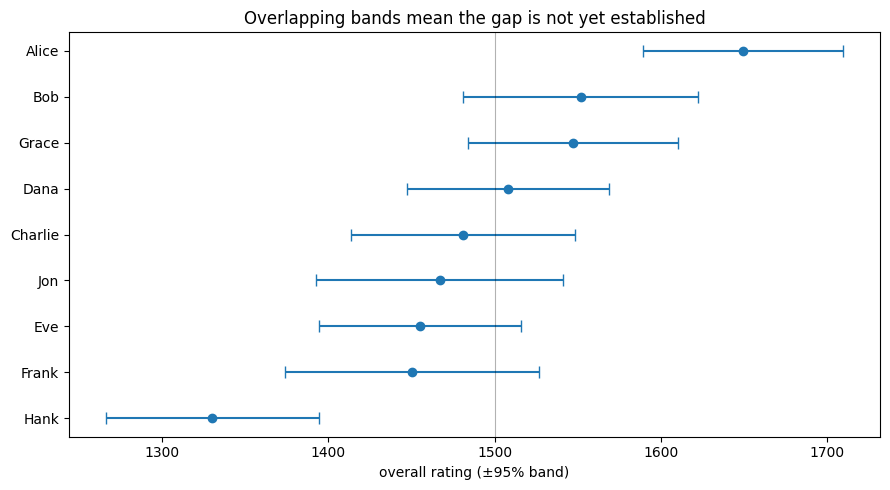

provisional (rating shown, unranked):
  Ivy        1559.5 ± 201.5   (40 career matches)


In [13]:
ranked = board[~board.is_provisional].sort_values("current")
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(ranked.current, range(len(ranked)),
            xerr=CONFIDENCE_Z * ranked.rd, fmt="o", capsize=4)
ax.set_yticks(range(len(ranked)))
ax.set_yticklabels(ranked.index)
ax.axvline(RATING_MEAN, lw=0.8, color="black", alpha=0.3)
ax.set_xlabel("overall rating (±95% band)")
ax.set_title("Overlapping bands mean the gap is not yet established")
plt.tight_layout()
plt.show()

prov = board[board.is_provisional]
if len(prov):
    print("provisional (rating shown, unranked):")
    for p, r in prov.iterrows():
        print(f"  {p:<9} {r.current:>7.1f} ± {CONFIDENCE_Z * r.rd:>5.1f}   "
              f"({int(r.career_matches)} career matches)")

The bands are the point. If two players' intervals overlap heavily, presenting them as rank 3 and
rank 4 implies a precision the data does not support. Showing the band is more honest than showing
the ordinal alone, and it costs one extra column.

---
## 10. Seasonal vs overall, side by side

This is the plot that justifies having both numbers. To draw it, the seasonal rating is rebuilt
from the *same* `match_events` with seasonal parameters and boundary regression applied.

In [14]:
# --- seasonal rebuild (parameters from the seasonal notebook) ---------------
LAMBDA_REGRESSION = 0.70
SEASONAL_K = [(10, 48.0), (30, 32.0), (None, 20.0)]


def seasonal_k(n):
    for cutoff, k in SEASONAL_K:
        if cutoff is None or n < cutoff:
            return k


def run_seasonal_multi(matches):
    """Seasonal Elo across several seasons, regressing at each boundary."""
    ratings, counts, events = {}, defaultdict(int), []
    current_season = None

    for m in sorted(matches, key=lambda x: x.played_at):
        if m.season_id != current_season:
            if current_season is not None:
                ratings = {p: RATING_MEAN + LAMBDA_REGRESSION * (r - RATING_MEAN)
                           for p, r in ratings.items()}
            counts = defaultdict(int)          # counters reset every season
            current_season = m.season_id

        a, b, s_a = m.player_a, m.player_b, m.result
        ra = ratings.get(a, INITIAL_RATING)
        rb = ratings.get(b, INITIAL_RATING)
        k = min(seasonal_k(counts[a]), seasonal_k(counts[b]))
        new_a, new_b = update_ratings(ra, rb, s_a, k=k)
        ratings[a], ratings[b] = new_a, new_b
        counts[a] += 1
        counts[b] += 1

        for player, after in ((a, new_a), (b, new_b)):
            events.append({"played_at": m.played_at, "season_id": m.season_id,
                           "player_id": player, "rating_after": after})

    return ratings, pd.DataFrame(events)


seasonal_ratings, seasonal_events = run_seasonal_multi(CAREER)
print("seasonal rebuild complete:", len(seasonal_events), "events")

seasonal rebuild complete: 3200 events


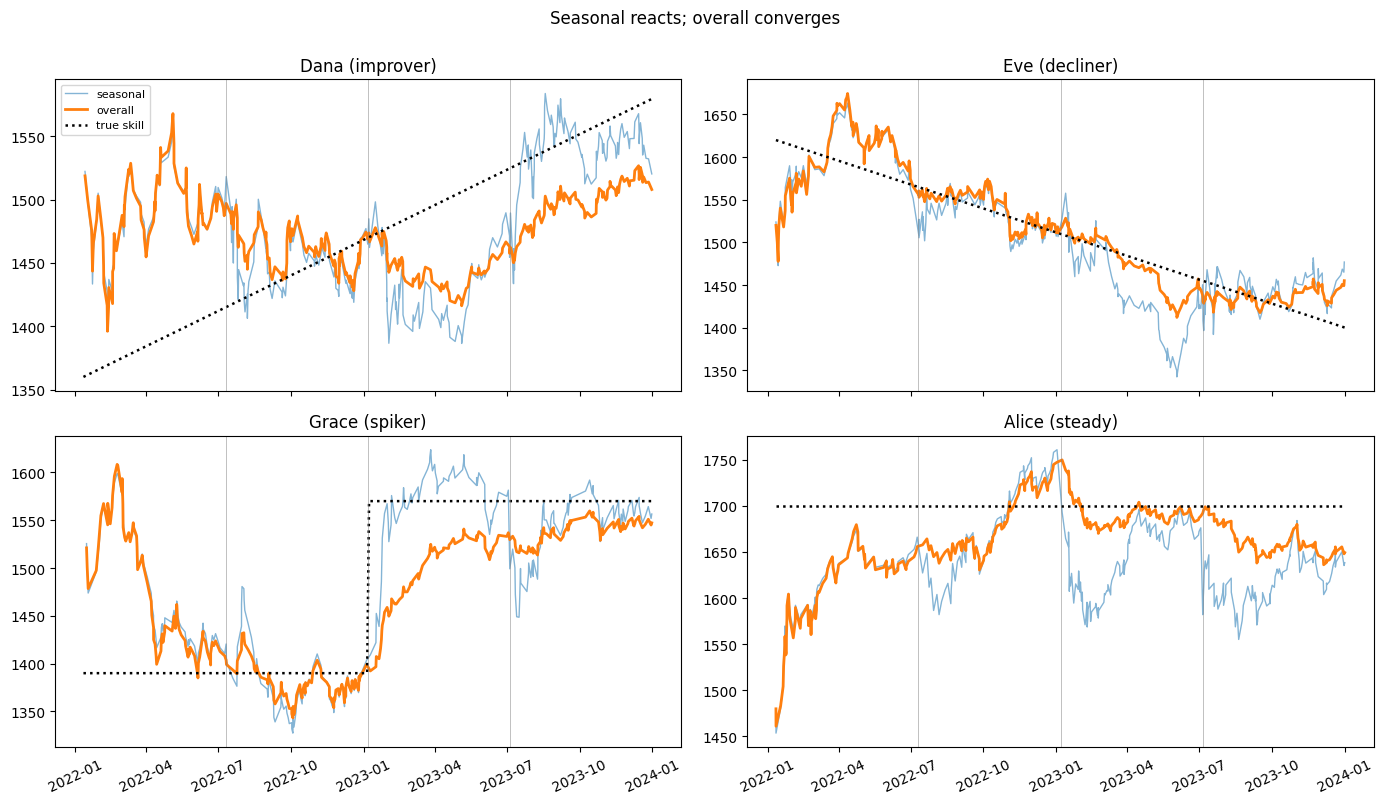

In [15]:
focus = ["Dana", "Eve", "Grace", "Alice"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, name in zip(axes.ravel(), focus):
    o = overall_events[overall_events.player_id == name].sort_values("played_at")
    s = seasonal_events[seasonal_events.player_id == name].sort_values("played_at")

    ax.plot(s.played_at, s.rating_after, lw=1.0, alpha=0.55, label="seasonal")
    ax.plot(o.played_at, o.rating_after, lw=2.0, label="overall")

    t = [SKILL_AT[name](d) for d in np.linspace(0, CAREER_DAYS, 300)]
    xs = [match_events.played_at.min() + timedelta(days=d)
          for d in np.linspace(0, CAREER_DAYS, 300)]
    ax.plot(xs, t, ls=":", lw=1.8, color="black", label="true skill")

    for sn in range(1, 4):
        ax.axvline(match_events.played_at.min() + timedelta(days=sn * SEASON_LENGTH),
                   lw=0.7, color="grey", alpha=0.5)

    ax.set_title(f"{name} ({ARCHETYPE[name]})")
    ax.tick_params(axis="x", rotation=25)

axes[0, 0].legend(fontsize=8)
fig.suptitle("Seasonal reacts; overall converges", y=1.00)
plt.tight_layout()
plt.show()

In [16]:
# Quantify it: which rating tracks true skill better, and which is steadier?
def track_error(events, col="rating_after"):
    d = events.copy()
    day0 = match_events.played_at.min()
    d["day"] = (d.played_at - day0).dt.total_seconds() / 86400
    d["true"] = [SKILL_AT[p](x) for p, x in zip(d.player_id, d.day)]
    d["abs_err"] = (d[col] - d["true"]).abs()
    # Elo recovers differences, not levels: remove the constant population offset
    # so this measures tracking quality rather than where the scale happens to sit.
    d["centred_err"] = (d[col] - d[col].mean()) - (d["true"] - d["true"].mean())
    d["centred_abs_err"] = d.centred_err.abs()
    return d


o_err = track_error(overall_events)
s_err = track_error(seasonal_events)

summary = pd.DataFrame({
    "overall_MAE":  o_err.groupby("player_id").centred_abs_err.mean(),
    "seasonal_MAE": s_err.groupby("player_id").centred_abs_err.mean(),
    "overall_stdev":  overall_events.groupby("player_id").rating_after.std(),
    "seasonal_stdev": seasonal_events.groupby("player_id").rating_after.std(),
}).assign(archetype=lambda d: d.index.map(ARCHETYPE))

summary["winner"] = np.where(summary.overall_MAE < summary.seasonal_MAE,
                             "overall", "seasonal")

print("means (offset-corrected):")
print(summary[["overall_MAE", "seasonal_MAE",
               "overall_stdev", "seasonal_stdev"]].mean().round(1).to_string())
print()
print("accuracy winner by archetype:")
print(summary.groupby(["archetype", "winner"]).size().to_string())
summary.sort_values(["archetype", "overall_MAE"])

means (offset-corrected):
overall_MAE      29.6
seasonal_MAE     36.0
overall_stdev    36.6
seasonal_stdev   45.0

accuracy winner by archetype:
archetype  winner  
decliner   overall     1
improver   seasonal    1
spiker     seasonal    1
steady     overall     7


,overall_MAE,seasonal_MAE,overall_stdev,seasonal_stdev,archetype,winner
player_id,,,,,,
Eve,22.2,30.9,68.9,73.5,decliner,overall
Dana,56.8,51.1,29.2,48.9,improver,seasonal
Grace,48.7,42.5,70.9,84.9,spiker,seasonal
Jon,18.2,22.6,22.4,26.9,steady,overall
Bob,19.7,31.3,23.0,37.2,steady,overall
Ivy,20.2,24.5,23.9,22.1,steady,overall
Hank,20.6,33.4,29.1,40.5,steady,overall
Charlie,22.9,30.0,27.6,35.2,steady,overall
Frank,27.1,27.4,28.7,32.6,steady,overall


This is the result worth internalising, and it is **not** a blanket win for the overall rating.

**Overall is less jumpy across the board** — its rating stdev is clearly lower for every archetype.
That part is unambiguous.

**Accuracy splits by archetype.** Overall wins on every steady player and on the decliner. Seasonal
wins on the improver and the spiker — the two players whose true strength is actively moving. That
is the K floor doing exactly what section 5 predicted: buying stability by paying lag, and the bill
lands specifically on people who are changing.

So neither rating dominates, and that is the argument for shipping both:

- **Overall** answers *"how strong is this competitor?"* — trust it for seeding, matchmaking, and
  career comparison.
- **Seasonal** answers *"what is happening right now?"* — trust it for a live leaderboard and for
  spotting someone on the way up before the career number catches on.

Label them clearly and never average them into one score. Blending destroys the property that makes
each one useful, and leaves you with a number that is neither stable nor responsive.

---
## 11. What the overall rating is actually for

A rating that cannot predict anything is just a leaderboard decoration. The real test of the
overall rating is out-of-sample: **fit on early career, predict late-career match outcomes.**

Compare against two baselines — coin flip, and overall win-rate — using Brier score
(mean squared error on the predicted probability; lower is better).

In [17]:
split_day = 3 * SEASON_LENGTH
day0 = match_events.played_at.min()
split_at = day0 + timedelta(days=split_day)

train = [m for m in CAREER if m.played_at <= split_at]
test  = [m for m in CAREER if m.played_at > split_at]
print(f"train: {len(train)} matches   test: {len(test)} matches")

train_ratings, train_counts, train_events = run_overall(train, policy="plain")

# Baseline: raw win rate over the training window.
wr = {}
for m in train:
    for p, s in ((m.player_a, m.result), (m.player_b, 1.0 - m.result)):
        w, n = wr.get(p, (0.0, 0))
        wr[p] = (w + s, n + 1)
win_rate = {p: (w / n if n else 0.5) for p, (w, n) in wr.items()}


def brier(pairs):
    return float(np.mean([(p - a) ** 2 for p, a in pairs]))


elo_pairs, wr_pairs, coin_pairs = [], [], []
for m in test:
    a, b, actual = m.player_a, m.player_b, m.result
    ra = train_ratings.get(a, INITIAL_RATING)
    rb = train_ratings.get(b, INITIAL_RATING)
    elo_pairs.append((expected_score(ra, rb), actual))

    wa, wb = win_rate.get(a, 0.5), win_rate.get(b, 0.5)
    wr_pairs.append((wa / (wa + wb) if (wa + wb) else 0.5, actual))
    coin_pairs.append((0.5, actual))

scores = pd.DataFrame({
    "model": ["overall Elo", "career win rate", "coin flip"],
    "brier": [brier(elo_pairs), brier(wr_pairs), brier(coin_pairs)],
}).assign(skill_vs_coin=lambda d: 1 - d.brier / d.brier.iloc[-1])

print(scores.to_string(index=False,
                       formatters={"brier": "{:.4f}".format,
                                   "skill_vs_coin": "{:+.1%}".format}))

train: 1156 matches   test: 444 matches
          model  brier skill_vs_coin
    overall Elo 0.2040        +10.3%
career win rate 0.2077         +8.7%
      coin flip 0.2275         +0.0%


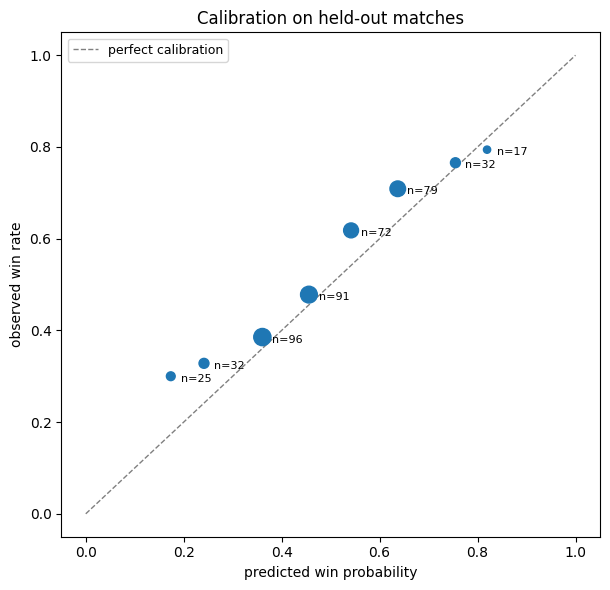

In [18]:
# Calibration: when the rating says 70%, does it happen ~70% of the time?
cal = pd.DataFrame(elo_pairs, columns=["pred", "actual"])
cal["bucket"] = pd.cut(cal.pred, bins=np.arange(0, 1.05, 0.1))
grp = cal.groupby("bucket", observed=True).agg(
    predicted=("pred", "mean"), observed=("actual", "mean"), n=("actual", "size")
).dropna()

fig, ax = plt.subplots(figsize=(6.2, 6))
ax.plot([0, 1], [0, 1], ls="--", lw=1, color="grey", label="perfect calibration")
ax.scatter(grp.predicted, grp.observed, s=grp.n * 1.6, zorder=3)
for _, r in grp.iterrows():
    ax.annotate(f"n={int(r.n)}", (r.predicted, r.observed),
                textcoords="offset points", xytext=(7, -4), fontsize=8)
ax.set_xlabel("predicted win probability")
ax.set_ylabel("observed win rate")
ax.set_title("Calibration on held-out matches")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

If the points sit near the diagonal, the overall rating is not just ordering players — it is
producing win probabilities you can actually use, for seeding, matchmaking, or handicapping.

Keep this cell. It is the regression test that matters: change the K schedule or the decay policy,
re-run, and if the Brier score gets worse you made the system worse regardless of how the
leaderboard looks.

---
## 12. Schema and persistence

```
match_events(match_id, season_id, played_at, player_a, player_b, result)   -- BRONZE

rating_events(...)            -- SILVER, seasonal parameters, boundary applied
overall_rating_events(event_id, match_id, season_id, played_at, player_id,
                      opponent_id, result, rating_before, rating_after,
                      delta, k_used, career_matches_after)   -- SILVER

overall_standings(player_id, current_rating, peak_rating, prime_rating,
                  trough_rating, rd, lo, hi, career_matches, wins, draws,
                  losses, first_played, last_played, volatility,
                  is_provisional, rank)   -- GOLD

rating_policies(policy_id, applies_to, k_tiers_json, lambda_regression,
                min_matches, rd_params_json, created_at)
```

Two silver logs, one bronze source, and both replayable. `rating_policies` is what makes the whole
thing auditable: when a leaderboard changes, you want to be able to say whether the *results*
changed or the *parameters* did.

In [19]:
import os, json

os.makedirs("data", exist_ok=True)

overall_rating_events = overall_events.copy()
overall_rating_events.insert(0, "event_id",
                             [f"O{i:06d}" for i in range(len(overall_rating_events))])

overall_standings = board.rename(columns={
    "current": "current_rating", "peak": "peak_rating",
    "prime": "prime_rating", "trough": "trough_rating",
}).drop(columns=["archetype", "true_skill_now"], errors="ignore").reset_index()

rating_policies = pd.DataFrame([
    {"policy_id": "overall_v1", "applies_to": "overall",
     "k_tiers_json": json.dumps(K_CAREER_TIERS), "lambda_regression": None,
     "min_matches": MIN_CAREER_MATCHES,
     "rd_params_json": json.dumps({"base": RD_BASE, "idle_beta": RD_IDLE_BETA,
                                   "floor": RD_FLOOR, "ceiling": RD_CEILING})},
    {"policy_id": "seasonal_v1", "applies_to": "seasonal",
     "k_tiers_json": json.dumps(SEASONAL_K),
     "lambda_regression": LAMBDA_REGRESSION, "min_matches": 10,
     "rd_params_json": None},
]).assign(created_at=datetime.now())

for name, df in [("match_events", match_events),
                 ("overall_rating_events", overall_rating_events),
                 ("overall_standings", overall_standings),
                 ("rating_policies", rating_policies)]:
    df.to_csv(f"data/{name}.csv", index=False)
    print(f"data/{name}.csv".ljust(38), f"{len(df):>6} rows")

data/match_events.csv                    1600 rows
data/overall_rating_events.csv           3200 rows
data/overall_standings.csv                 10 rows
data/rating_policies.csv                    2 rows


In [20]:
# The whole overall rating must be a pure function of (match_events, policy).
rerun, _, _ = run_overall(CAREER, policy="plain")
diff = max(abs(rerun[p] - overall_ratings[p]) for p in overall_ratings)
print(f"max difference on full replay: {diff:.12f}")
assert diff < 1e-9, "overall rating is NOT deterministic from match_events"

rebuilt_stats = career_stats(overall_events)
delta = (rebuilt_stats.current - stats.current).abs().max()
assert delta < 1e-9, "standings are NOT reproducible from the event log"
print("overall rating is deterministic and standings are a pure view ✓")

max difference on full replay: 0.000000000000
overall rating is deterministic and standings are a pure view ✓


---
## 13. Connections to the other two ratings

With seasonal and overall both built, the remaining two are mostly queries rather than new
algorithms:

| Rating | Reads from | Core idea |
|---|---|---|
| **Prosperity** | `overall_rating_events` + `rating_events` | `current - prime` for direction, `volatility` for control, season-over-season deltas for progression |
| **Thinkers** | strategy markers joined to `delta` | did a strategy change precede a sustained improvement, or churn? |

Two columns this notebook produces that Prosperity needs directly:

- **`prime` vs `current`** — career direction, already computed in section 8. A player near their
  prime is holding form; far below it is declining; above it is peaking now.
- **`volatility`** (stdev of `delta`) — controlled consistency versus swinging wildly. Note this is
  partly an artifact of K, so normalize by the K actually used before comparing across players at
  different career stages.

### Next steps for the repo

1. `src/elo.py` — `expected_score`, `update_ratings` (already shared by both notebooks)
2. `src/overall.py` — `career_k`, `run_overall`, `career_stats`, `rating_deviation`
3. `src/policies.py` — load K tiers and λ from the `rating_policies` table, not from constants
4. Persist `overall_rating_events` as partitioned Parquet or a Delta table; it is append-only, so
   partition by `season_id` and never update in place
5. Keep the section 11 backtest as a scheduled job. Brier score against held-out matches is the
   only number that tells you whether a parameter change helped
6. `GET /overall?as_of=` — same replay pattern as the seasonal endpoint